# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 2: EDA + ETL

En este notebook se realiza la preparación técnica del dataset para el sistema de recomendación.

A diferencia del notebook exploratorio, aquí se aplican procesos de limpieza, integración y transformación de datos con el objetivo de construir un dataset final consistente, interpretable y listo para modelado.

## Objetivo del notebook

El objetivo de este notebook es construir el dataset final para el sistema de recomendación mediante un proceso de ETL que incluya:

- limpieza de valores faltantes críticos;
- integración de tablas principales;
- validación de consistencia en los merges;
- creación de variables derivadas relevantes para el modelo;
- generación de un dataset final listo para la etapa de modelado.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
# ================================
# CARGA DE DATOS (vía kagglehub)
# ================================
import kagglehub
import os

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset descargado en:", path)
print("Archivos:", os.listdir(path))

customers   = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
orders      = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
products    = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
payments    = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
sellers     = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))

Dataset descargado en: C:\Users\Daniel\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
Archivos: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [15]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)


## Decisiones de limpieza y transformación

En esta etapa se aplican cambios permanentes sobre los datos, a diferencia del notebook de EDA.

Las decisiones de limpieza se enfocan en variables críticas para el sistema de recomendación. En particular:

- se preservan las columnas necesarias para relacionar usuarios, órdenes y productos;
- se eliminan registros faltantes en variables esenciales para el modelado;
- se prioriza la consistencia estructural del dataset final por encima de la completitud total.

______________________________________________________________________________

### Tratamiento de valores faltantes críticos

Se eliminan registros faltantes en variables indispensables para el sistema de recomendación.

En particular:

- `product_id` es necesario para identificar interacciones;
- `product_category_name` resulta clave para incorporar información de contenido;
- `customer_id` es necesario para vincular órdenes con clientes.

Dado que la proporción de estos faltantes es reducida, su eliminación no compromete la representatividad general del dataset.

In [16]:
order_items = order_items.dropna(subset=["product_id"])
products = products.dropna(subset=["product_category_name"])
orders = orders.dropna(subset=["customer_id"])

### Conversión de variables temporales

Se transforma la fecha de compra a formato `datetime` para habilitar la construcción de variables temporales, especialmente métricas de recencia.

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

##  Integración de tablas

La integración se realiza en etapas para controlar el impacto de cada merge sobre el volumen del dataset.

Esto permite verificar que no se estén perdiendo registros clave ni generando duplicaciones inesperadas.

In [4]:
print("Shape inicial order_items:", order_items.shape)
df = order_items.merge(orders, on="order_id", how="inner")
print("Después de merge con orders:", df.shape)

df = df.merge(customers, on="customer_id", how="inner")
print("Después de merge con customers:", df.shape)

df = df.merge(products, on="product_id", how="inner")
print("Después de merge con products:", df.shape)

df = df.merge(payments, on="order_id", how="left")
print("Después de merge con payments:", df.shape)

Shape inicial order_items: (112650, 7)
Después de merge con orders: (112650, 14)
Después de merge con customers: (112650, 18)
Después de merge con products: (112650, 26)
Después de merge con payments: (117604, 30)


### Validación de integridad en merges

Se observa una reducción en la cantidad de registros tras la integración con la tabla de productos.

Esto indica que existen registros en `order_items` cuyo `product_id` no tiene correspondencia en la tabla de productos.

Dado que la información de producto (especialmente la categoría) es clave para el sistema de recomendación, se decide conservar únicamente los registros con información consistente.

Esta decisión prioriza la calidad del dataset final por sobre la completitud total de los datos.

In [20]:
rows_before = order_items.shape[0]
rows_after = df.shape[0]

diff = rows_after - rows_before
diff_pct = (diff / rows_before) * 100

if diff > 0:
    print(f"Filas adicionales: {diff} (+{diff_pct:.2f}%)")
else:
    print(f"Filas perdidas: {-diff} ({diff_pct:.2f}%)")

Filas adicionales: 3256 (+2.89%)


### Expansión del dataset tras integración con pagos

Se observa un incremento en la cantidad de registros tras la integración con la tabla de pagos.

Esto ocurre porque una misma orden puede estar asociada a múltiples registros de pago, lo que genera duplicación de filas al realizar el merge.

Dado que la variable `payment_value` resulta relevante para capturar el valor económico de las transacciones, se decide conservar esta estructura, asumiendo que el impacto en la duplicación será tratado en la etapa de agregación o modelado.

In [21]:
df.isnull().sum().sort_values(ascending=False).head(10)

order_delivered_customer_date    2497
order_delivered_carrier_date     1207
order_approved_at                  14
payment_installments                3
payment_type                        3
payment_sequential                  3
payment_value                       3
product_height_cm                   1
product_length_cm                   1
product_weight_g                    1
dtype: int64

### Interpretación de valores faltantes

Los valores faltantes más relevantes se concentran en variables logísticas y temporales asociadas al proceso de aprobación y entrega de pedidos.

Dado que estas columnas no forman parte de las variables críticas del sistema de recomendación, no se utilizarán como criterio principal de limpieza final.

La limpieza se enfocará en las variables derivadas necesarias para el modelado, especialmente aquellas vinculadas a comportamiento del cliente, popularidad del producto, rating y valor económico.

In [32]:
purchase_frequency = df.groupby("customer_unique_id")["order_id"].nunique()
df["customer_purchase_count"] = df["customer_unique_id"].map(purchase_frequency)

In [33]:
product_popularity = df["product_id"].value_counts()
df["product_popularity"] = df["product_id"].map(product_popularity)

In [34]:
reviews_products = reviews.merge(
    order_items[["order_id", "product_id"]],
    on="order_id",
    how="inner"
)

avg_rating = reviews_products.groupby("product_id")["review_score"].mean()
df["product_rating"] = df["product_id"].map(avg_rating)

In [45]:
print("Pedidos con review:", df["product_rating"].notnull().sum())
print("Pedidos sin review:", df["product_rating"].isnull().sum())

Pedidos con review: 115696
Pedidos sin review: 0


## 🔍 Validación de disponibilidad de ratings

Se observa que el dataset final contiene:
- **Pedidos con rating:** 115.696  
- **Pedidos sin rating:** 0  

> **Hallazgo clave:** Todos los registros del dataset final cuentan con una calificación (`product_rating`).

Este resultado se debe a que, durante el proceso de integración, se realizó un `merge` interno (`inner join`) con la tabla de reviews.

Como consecuencia:
- Solo se conservaron las interacciones que tienen información de reseña
- Se eliminaron registros sin calificación disponible

### Implicancias para el sistema de recomendación

- Se garantiza que todos los productos incluidos tienen una señal explícita de calidad
- El modelo podrá apoyarse en el rating como variable confiable
- Se reduce el ruido asociado a productos sin evaluación

Sin embargo, este enfoque implica perder parte del dataset original, lo cual debe ser considerado en el análisis de cobertura del sistema.

In [46]:
customer_total_spend = df.groupby("customer_unique_id")["payment_value"].sum()
df["customer_total_spend"] = df["customer_unique_id"].map(customer_total_spend)

In [50]:
fecha_referencia = df["order_purchase_timestamp"].max()

ultima_compra_por_cliente = df.groupby("customer_unique_id")["order_purchase_timestamp"].max()

df["last_purchase"] = df["customer_unique_id"].map(ultima_compra_por_cliente)

df["days_since_last_purchase"] = df["customer_unique_id"].map(
    lambda uid: (fecha_referencia - ultima_compra_por_cliente[uid]).days
)

### Recencia de compra

La variable `days_since_last_purchase` se calcula como la diferencia entre la última compra registrada de cada cliente y la fecha máxima disponible en el dataset.

Este enfoque permite medir correctamente qué tan reciente es la actividad del usuario dentro del sistema y resulta más adecuado que comparar cada orden contra la última compra del mismo cliente.

In [37]:
df = df.dropna(subset=[
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase"
])

In [38]:
df_model = df[[
    "customer_unique_id",
    "product_id",
    "product_category_name",
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase"
]]

In [41]:
print(df_model.shape)
df_model.head()

(115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,0
1,eb28e67c4c0b83846050ddfb8a35d051,e5f2d52b802189ee658865ca93d83a8f,pet_shop,2,1,4.000000,284.56,146
2,3818d81c6709e39d06b2738a8d3a2474,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,1,3,4.333333,216.87,0
3,af861d436cfc08b2c2ddefd0ba074622,7634da152a4610f1595efa32f14722fc,perfumaria,1,2,4.000000,25.78,0
4,64b576fb70d441e8f1b2d7d446e483c5,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,1,12,3.833333,218.04,0


### Dataset final para modelado

El dataset final resultante contiene 115.696 registros y 8 variables relevantes para el sistema de recomendación.

Cada fila representa una interacción usuario-producto enriquecida con información de comportamiento, popularidad, calidad, valor económico y recencia.

Las variables incluidas son:

- `customer_unique_id`: identificador único del cliente;
- `product_id`: identificador del producto;
- `product_category_name`: categoría del producto;
- `customer_purchase_count`: cantidad de compras realizadas por el cliente;
- `product_popularity`: frecuencia de interacción del producto;
- `product_rating`: calificación promedio del producto;
- `customer_total_spend`: gasto total acumulado del cliente;
- `days_since_last_purchase`: recencia de compra del cliente.

Este dataset se considera apto para la etapa de modelado del sistema de recomendación.

_____________________________________________________________________________________

## Análisis económico de órdenes y clientes

Antes de continuar con el proceso de feature engineering, se realiza una revisión exploratoria de variables económicas relevantes para el problema de negocio.

En particular, se analiza:

- el ticket por orden;
- el gasto total por cliente.

Estas métricas se relacionan directamente con el objetivo del proyecto de aumentar el ticket promedio y mejorar el valor del cliente.

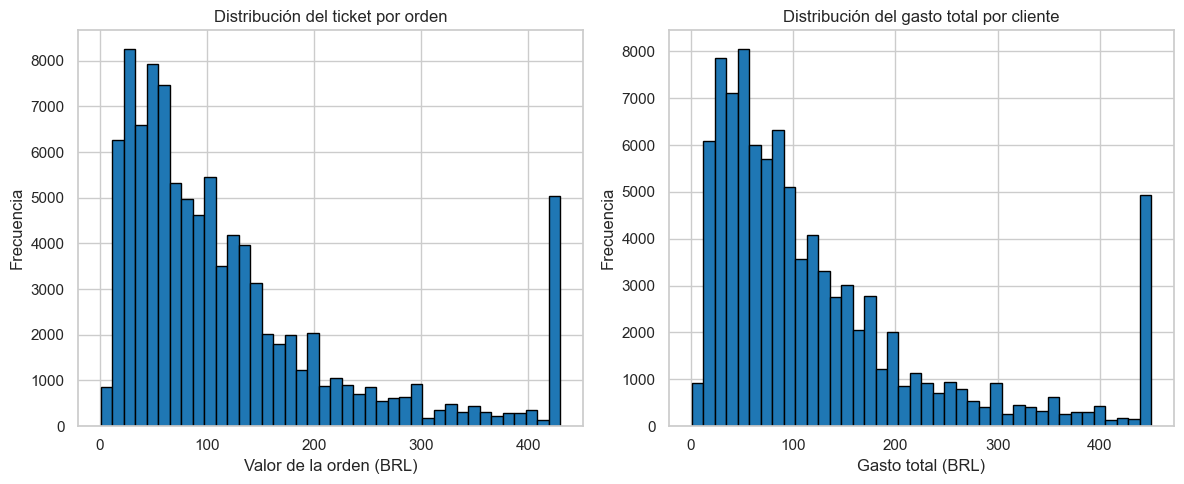

Ticket promedio por orden: BRL 143.97
Mediana del ticket por orden: BRL 89.00


In [51]:
ticket_por_orden = df.groupby("order_id")["price"].sum()
gasto_por_cliente = df.groupby("customer_unique_id")["price"].sum()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ticket_por_orden.clip(upper=ticket_por_orden.quantile(0.95)).hist(
    bins=40, color="#1f77b4", edgecolor="black"
)
plt.title("Distribución del ticket por orden")
plt.xlabel("Valor de la orden (BRL)")
plt.ylabel("Frecuencia")

plt.subplot(1, 2, 2)
gasto_por_cliente.clip(upper=gasto_por_cliente.quantile(0.95)).hist(
    bins=40, color="#1f77b4", edgecolor="black"
)
plt.title("Distribución del gasto total por cliente")
plt.xlabel("Gasto total (BRL)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"Ticket promedio por orden: BRL {ticket_por_orden.mean():.2f}")
print(f"Mediana del ticket por orden: BRL {ticket_por_orden.median():.2f}")

## Análisis del ticket por orden y gasto por cliente

El análisis de las variables económicas muestra los siguientes resultados:

- **Ticket promedio por orden:** BRL 143.97  
- **Mediana del ticket por orden:** BRL 89.00  

> **Hallazgo clave:** La media es considerablemente mayor que la mediana, lo que indica una distribución sesgada hacia la derecha.

### Interpretación

Los histogramas muestran que:

- La mayoría de las órdenes se concentran en valores bajos o medios
- Existe un conjunto reducido de órdenes con valores significativamente altos
- El gasto total por cliente también presenta una fuerte dispersión

Este comportamiento es típico en plataformas de e-commerce, donde:

- pocos clientes concentran gran parte del valor total
- la mayoría realiza compras de bajo monto

### 🎯 Implicancias para el sistema de recomendación

- El sistema puede ser utilizado no solo para mejorar relevancia, sino también para:
  - aumentar el ticket promedio
  - incentivar compras adicionales (cross-selling)
- La existencia de clientes de alto valor permite explorar estrategias de personalización diferenciadas

En conjunto, este análisis refuerza la importancia de incorporar variables económicas en el modelo.

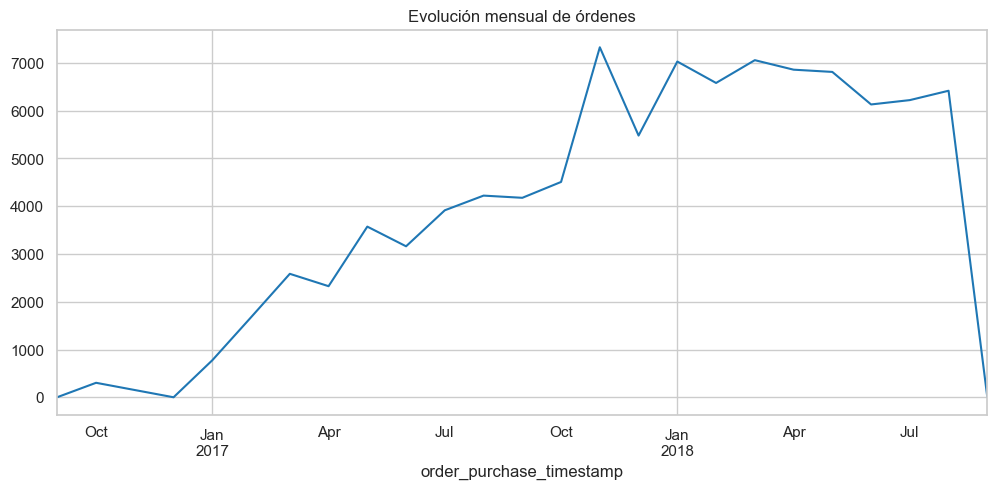

In [52]:
ventas_mensuales = df.groupby(
    df["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].nunique()

plt.figure(figsize=(12,5))
ventas_mensuales.plot(color="#1f77b4")
plt.title("Evolución mensual de órdenes")
plt.show()

## Análisis temporal de la demanda

Se analiza la evolución mensual de la cantidad de órdenes con el objetivo de identificar patrones de crecimiento, estacionalidad y posibles anomalías en el comportamiento del marketplace.

### Observaciones principales

- Se observa una **tendencia creciente** en la cantidad de órdenes a lo largo del tiempo.
- Existen **picos de actividad** en determinados períodos, lo que sugiere eventos comerciales o estacionales (por ejemplo, promociones o campañas).
- Hacia el final del período se registra una **caída abrupta**, lo cual puede deberse a:
  - datos incompletos del último mes  
  - corte del dataset  
  - o un período parcial no representativo  

> **Hallazgo clave:** La demanda no es estable en el tiempo, sino que presenta variaciones significativas.

### Interpretación

Este comportamiento indica que:

- los usuarios no compran de forma uniforme
- existen momentos de alta concentración de actividad
- el sistema debe ser capaz de adaptarse a cambios en la demanda

### Riesgos identificados

- un modelo estático podría no capturar correctamente estas variaciones
- ignorar la dimensión temporal puede generar recomendaciones desactualizadas

### Implicancias para el sistema de recomendación

A partir de este análisis, se concluye que:

- es importante considerar la **recencia de las interacciones**  
- se justifica la inclusión de variables como `days_since_last_purchase`  
- el modelo podría beneficiarse de enfoques que ponderen más las interacciones recientes  

Además, este comportamiento refuerza la necesidad de:

- actualizar periódicamente el modelo  
- incorporar lógica temporal en las recomendaciones  


____________________________________________________________________________________

In [48]:
n_users = df_model["customer_unique_id"].nunique()
n_products = df_model["product_id"].nunique()
n_interactions = df_model.shape[0]

density = (n_interactions / (n_users * n_products)) * 100

print(f"Usuarios únicos: {n_users}")
print(f"Productos únicos: {n_products}")
print(f"Interacciones: {n_interactions}")
print(f"Densidad: {density:.4f}%")

Usuarios únicos: 93976
Productos únicos: 32184
Interacciones: 115696
Densidad: 0.0038%


## 🧮 Análisis de Sparsity de la matriz usuario-producto

Para evaluar la viabilidad de construir un sistema de recomendación basado en comportamiento, se analiza la **densidad de la matriz usuario-producto**, es decir, qué proporción de todas las posibles interacciones entre usuarios y productos está presente en el dataset.

### Resultados

- **Usuarios únicos:** 93,976  
- **Productos únicos:** 32,184  
- **Interacciones observadas:** 115,696  
- **Densidad de la matriz:** 0.0038%  

> 💡 **Hallazgo clave:** La matriz es extremadamente dispersa.

### Interpretación

La densidad obtenida indica que:

- más del **99.99% de las posibles interacciones están vacías**
- la mayoría de los usuarios interactúa con muy pocos productos
- existe una fuerte limitación de información por usuario

Este comportamiento es característico de plataformas de e-commerce con catálogos amplios y baja recurrencia de compra.

### Implicancias técnicas

El alto nivel de sparsity implica que:

- será difícil encontrar usuarios con patrones de consumo similares  
- los modelos basados únicamente en historial pueden tener bajo rendimiento  
- se presenta el problema de **cold start** (usuarios o productos con poca información)

### Impacto en el modelado

Dado este contexto, el sistema de recomendación deberá:

- incorporar variables adicionales como:
  - popularidad del producto  
  - rating promedio  
  - recencia de compra  
- considerar enfoques más robustos como:
  - filtrado colaborativo (SVD, ALS)  
  - modelos híbridos (contenido + comportamiento)

Este análisis justifica la necesidad de enriquecer el dataset más allá de las interacciones directas.

In [49]:
df_model.to_csv("../data/dataset_modelo.csv", index=False)

### Exportación del dataset

Se exporta el dataset final procesado en formato CSV para ser utilizado en la etapa de modelado del sistema de recomendación.